### Modélisation : Dans cette phase finale, nous entrainerons nos modèles et identifierons celui qui nous donne la meilleure performance pour notre prédiction.

In [30]:
# Importating necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
import pickle
import os
from tensorflow import keras
from tensorflow.keras import layers
import warnings
import optuna
from sklearn.ensemble import StackingRegressor
import json
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

In [31]:
# Loading the processed dataset train and test
train = pd.read_csv("../data/processed/train_clean.csv")
test = pd.read_csv("../data/processed/test_clean.csv")

In [32]:
# Separating features and target
X_train = train.drop(columns=['SalePrice'])
y_train = train['SalePrice']
test_ids = test['Id']
X_test = test.drop(columns=['Id'])

In [33]:
# Displaying the shapes of the datasets
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (1455, 222)
X_test:  (1459, 203)


In [34]:
# Aligning the columns of X_test with X_train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [35]:
# Scaling the features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [36]:
# Function to evaluate models using RMSLE with cross-validation
def rmsle_cv(model, X, y, n_folds=5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    scores = np.sqrt(-cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=kf))
    return scores

def print_score(name, scores):
    print(f"{name:25s} → RMSLE: {scores.mean():.4f} ± {scores.std():.4f}")

### Modélisation

In [37]:
# Linear Regression, Ridge, and Lasso models evaluation
lr   = LinearRegression()
ridge = Ridge(alpha=10)
lasso = Lasso(alpha=0.001)

for name, model in [("Linear Regression", lr), ("Ridge", ridge), ("Lasso", lasso)]:
    scores = rmsle_cv(model, X_train_scaled, y_train)
    print_score(name, scores)

Linear Regression         → RMSLE: 0.1317 ± 0.0176
Ridge                     → RMSLE: 0.1297 ± 0.0169
Lasso                     → RMSLE: 0.1261 ± 0.0165


In [38]:
# Random Forest Regressor evaluation
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
scores = rmsle_cv(rf, X_train, y_train)
print_score("Random Forest", scores)

Random Forest             → RMSLE: 0.1412 ± 0.0080


In [39]:
# XGBoost Regressor evaluation
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
scores = rmsle_cv(xgb_model, X_train, y_train)
print_score("XGBoost", scores)

XGBoost                   → RMSLE: 0.1246 ± 0.0082


In [40]:
# LightGBM Regressor evaluation
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05,
    max_depth=4, num_leaves=31,
    subsample=0.8, random_state=42
)
scores = rmsle_cv(lgb_model, X_train, y_train)
print_score("LightGBM", scores)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000985 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2583
[LightGBM] [Info] Number of data points in the train set: 1164, number of used features: 139
[LightGBM] [Info] Start training from score 12.028149
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [41]:
# Function to build ANN model
def build_ann(input_dim):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [42]:
# Scaling the target variable y for ANN
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
ann_scores = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
    X_tr, X_val = X_train_scaled.iloc[tr_idx], X_train_scaled.iloc[val_idx]
    y_tr, y_val = y_train_scaled[tr_idx], y_train_scaled[val_idx]

    model = build_ann(X_train_scaled.shape[1])
    model.fit(X_tr, y_tr, epochs=100, batch_size=32,
              validation_data=(X_val, y_val), verbose=0,
              callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)])

    preds = model.predict(X_val, verbose=0).flatten()
    preds_original = y_scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
    y_val_original = y_scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
    
    score = np.sqrt(mean_squared_error(y_val_original, preds_original))
    ann_scores.append(score)
    print(f"  Fold {fold+1}: {score:.4f}")

ann_scores = np.array(ann_scores)
print_score("ANN", ann_scores)

  Fold 1: 0.1381
  Fold 2: 0.1386
  Fold 3: 0.1269
  Fold 4: 0.1336
  Fold 5: 0.1591
ANN                       → RMSLE: 0.1393 ± 0.0108


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2583
[LightGBM] [Info] Number of data points in the train set: 1164, number of used features: 139
[LightGBM] [Info] Start training from score 12.028149
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

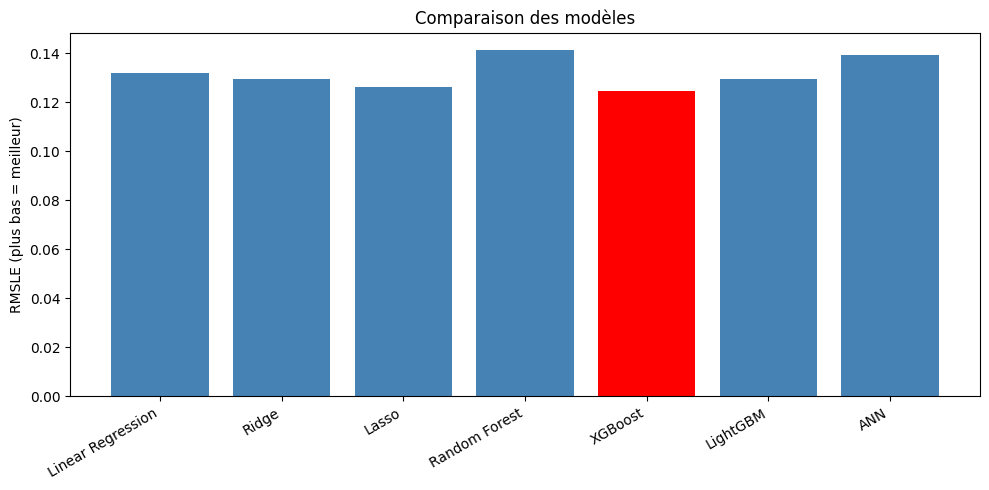


 Meilleur modèle : XGBoost (0.1246)


In [43]:
# Comparing all models
results = {
    "Linear Regression": rmsle_cv(lr, X_train_scaled, y_train).mean(),
    "Ridge":             rmsle_cv(ridge, X_train_scaled, y_train).mean(),
    "Lasso":             rmsle_cv(lasso, X_train_scaled, y_train).mean(),
    "Random Forest":     rmsle_cv(rf, X_train, y_train).mean(),
    "XGBoost":           rmsle_cv(xgb_model, X_train, y_train).mean(),
    "LightGBM":          rmsle_cv(lgb_model, X_train, y_train).mean(),
    "ANN":               ann_scores.mean()
}

plt.figure(figsize=(10, 5))
colors = ['red' if v == min(results.values()) else 'steelblue' for v in results.values()]
plt.bar(results.keys(), results.values(), color=colors)
plt.xticks(rotation=30, ha='right')
plt.ylabel("RMSLE (plus bas = meilleur)")
plt.title("Comparaison des modèles")
plt.tight_layout()
plt.show()

best_model_name = min(results, key=results.get)
print(f"\n Meilleur modèle : {best_model_name} ({results[best_model_name]:.4f})")

In [44]:
# Traning the best model on the entire training set and making predictions on the test set
best_models = {
    "Linear Regression": (lr, X_train_scaled, X_test_scaled),
    "Ridge":             (ridge, X_train_scaled, X_test_scaled),
    "Lasso":             (lasso, X_train_scaled, X_test_scaled),
    "Random Forest":     (rf, X_train, X_test),
    "XGBoost":           (xgb_model, X_train, X_test),
    "LightGBM":          (lgb_model, X_train, X_test)
}

if best_model_name == "ANN":
    final_model = build_ann(X_train_scaled.shape[1])
    final_model.fit(X_train_scaled, y_train_scaled, epochs=150, batch_size=32, verbose=0,
                    callbacks=[keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)])
    preds_normalized = final_model.predict(X_test_scaled, verbose=0).flatten()
    preds_log = y_scaler.inverse_transform(preds_normalized.reshape(-1, 1)).flatten()
    preds_final = np.expm1(preds_log)
else:
    final_model, X_tr, X_te = best_models[best_model_name]
    final_model.fit(X_tr, y_train)
    preds_log = final_model.predict(X_te)

In [45]:
# Save the best model in the models directory
best_models = {
    "Linear Regression": (lr, X_train_scaled, X_test_scaled),
    "Ridge":             (ridge, X_train_scaled, X_test_scaled),
    "Lasso":             (lasso, X_train_scaled, X_test_scaled),
    "Random Forest":     (rf, X_train, X_test),
    "XGBoost":           (xgb_model, X_train, X_test),
    "LightGBM":          (lgb_model, X_train, X_test),
    "ANN":               (model, X_train_scaled, X_test_scaled)
}

os.makedirs("../models", exist_ok=True)
if best_model_name == "ANN":
    final_model.save("../models/best_model_ann.keras")
    print("ANN sauvegardé → ../models/best_model_ann.keras")
else:
    with open(f"../models/best_model.pkl", "wb") as f:
        pickle.dump(final_model, f)
    print(f"{best_model_name} sauvegardé → ../models/best_model.pkl")

# Save the scaler for future use
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Scaler sauvegardé → ../models/scaler.pkl")
    

XGBoost sauvegardé → ../models/best_model.pkl
Scaler sauvegardé → ../models/scaler.pkl


In [46]:
# Inverse log1p
preds_final = np.expm1(preds_log)

In [47]:
# Saving the submission file
submission = pd.DataFrame({'Id': test_ids, 'SalePrice': preds_final})
submission.to_csv("../data/submission.csv", index=False)
print(submission.head())
print("submission.csv sauvegardé !")

     Id      SalePrice
0  1461  127174.531250
1  1462  161827.171875
2  1463  183700.953125
3  1464  193645.015625
4  1465  179680.109375
submission.csv sauvegardé !


## Hyperparameter Tuning

In [ ]:
# Hyperparameter tuning with Optuna for XGBoost
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
        'random_state': 42
    }
    model = xgb.XGBRegressor(**params)
    scores = rmsle_cv(model, X_train, y_train, n_folds=5)
    return scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\n Meilleurs paramètres : {study.best_params}")
print(f" Meilleur score CV   : {study.best_value:.4f}")

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
# Hyperparameter tuning with Optuna for LightGBM
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
        'random_state': 42,
        'verbose': -1
    }
    model = lgb.LGBMRegressor(**params)
    scores = rmsle_cv(model, X_train, y_train, n_folds=5)
    return scores.mean()

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=100, show_progress_bar=True)

print(f"Meilleur score LGB : {study_lgb.best_value:.4f}")
print(f"Meilleurs params   : {study_lgb.best_params}")

# Sauvegarder les params
with open("../models/best_lgb_params.json", "w") as f:
    json.dump(study_lgb.best_params, f, indent=4)
print("✅ Paramètres LGB sauvegardés")

In [ ]:
# Recreating the model directly with these parameters and making predictions on the test set
best_xgb = xgb.XGBRegressor(**study.best_params)
best_xgb.fit(X_train, y_train)
preds_log = best_xgb.predict(X_test)
preds_final = np.expm1(preds_log)

In [ ]:
# Saving the tuned model
submission = pd.DataFrame({'Id': test_ids, 'SalePrice': preds_final})
submission.to_csv("../data/submission_tuned.csv", index=False)
print(submission.head())
print("submission_tuned.csv sauvegardé !")

     Id      SalePrice
0  1461  126588.507812
1  1462  158259.890625
2  1463  186633.343750
3  1464  197684.421875
4  1465  183527.593750
submission_tuned.csv sauvegardé !


In [ ]:
# Save the best parameters after tuning 
best_params = study.best_params
with open("../models/best_xgb_params.json", "w") as f:
    json.dump(best_params, f, indent=4)
print("Paramètres sauvegardés → ../models/best_xgb_params.json")

Paramètres sauvegardés → ../models/best_xgb_params.json


## Stacking/Blending

In [ ]:
# Training the best models on the entire training set and making predictions on the test set for blending
xgb_final = xgb.XGBRegressor(**study.best_params)
xgb_final.fit(X_train, y_train)

lgb_final = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05,
    max_depth=4, num_leaves=31,
    subsample=0.8, random_state=42
)
lgb_final.fit(X_train, y_train)

ridge_final = Ridge(alpha=10)
ridge_final.fit(X_train_scaled, y_train)

# Predictions of each model 
preds_xgb   = xgb_final.predict(X_test)
preds_lgb   = lgb_final.predict(X_test)
preds_ridge = ridge_final.predict(X_test_scaled)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000402 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2648
[LightGBM] [Info] Number of data points in the train set: 1455, number of used features: 144
[LightGBM] [Info] Start training from score 12.022553
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [ ]:
# Comparing the CV scores of the blended model using KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
blend_scores = []

for tr_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    X_tr_s, X_val_s = X_train_scaled.iloc[tr_idx], X_train_scaled.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    # XGBoost
    m_xgb = xgb.XGBRegressor(**study.best_params)
    m_xgb.fit(X_tr, y_tr)
    p_xgb = m_xgb.predict(X_val)

    # LightGBM
    m_lgb = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05,
                               max_depth=4, num_leaves=31,
                               subsample=0.8, random_state=42)
    m_lgb.fit(X_tr, y_tr)
    p_lgb = m_lgb.predict(X_val)

    # Ridge
    m_ridge = Ridge(alpha=10)
    m_ridge.fit(X_tr_s, y_tr)
    p_ridge = m_ridge.predict(X_val_s)

    # Blend
    p_blend = 0.45 * p_xgb + 0.45 * p_lgb + 0.10 * p_ridge
    score = np.sqrt(mean_squared_error(y_val, p_blend))
    blend_scores.append(score)

blend_scores = np.array(blend_scores)
print_score("Blending (XGB+LGB+Ridge)", blend_scores)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000424 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2583
[LightGBM] [Info] Number of data points in the train set: 1164, number of used features: 139
[LightGBM] [Info] Start training from score 12.028149
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [ ]:
# Stacking Regressor with XGBoost, LightGBM, and Ridge as base models and Ridge as meta-model

estimators = [
    ('xgb', xgb.XGBRegressor(**study.best_params)),       
    ('lgb', lgb.LGBMRegressor(**study_lgb.best_params)),  
    ('ridge', Ridge(alpha=10))
]

stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=10),
    cv=5,
    n_jobs=-1
)

stack_scores = rmsle_cv(stacking, X_train, y_train)
print_score("Stacking", stack_scores)

Stacking                  → RMSLE: 0.1193 ± 0.0121


In [ ]:
# Evaluate the scores and decide which one to submit 
print(f"Blending score CV : {blend_scores.mean():.4f}")
print(f"Stacking score CV : {stack_scores.mean():.4f}")

if blend_scores.mean() < stack_scores.mean():
    preds_blend = (0.45 * preds_xgb + 0.45 * preds_lgb + 0.10 * preds_ridge)
    submission_blend = pd.DataFrame({'Id': test_ids, 'SalePrice': np.expm1(preds_blend)})
    submission_blend.to_csv("../data/submission_blend.csv", index=False)
    print("\n Blending gagne → soumission_blend.csv sauvegardé !")
else:
    stacking.fit(X_train, y_train)
    preds_stack = stacking.predict(X_test)
    submission_stack = pd.DataFrame({'Id': test_ids,'SalePrice': np.expm1(preds_stack)})
    submission_stack.to_csv("../data/submission_stack.csv", index=False)
    print("\n Stacking gagne → submission_stack.csv sauvegardé !")

Blending score CV : 0.1215
Stacking score CV : 0.1193

 Stacking gagne → submission_stack.csv sauvegardé !


## Conclusion

### Comparaison des modèles
- 6 modèles testés en cross-validation 5-fold : Linear Regression, Ridge, Lasso, Random Forest, XGBoost, LightGBM + ANN.
- **XGBoost** s'est révélé le meilleur modèle avec le RMSLE le plus bas en CV.

### Normalisation
- Les modèles linéaires (Linear Regression, Ridge, Lasso) et l'ANN ont été entraînés sur des données normalisées (`StandardScaler`).
- Les modèles basés sur des arbres (Random Forest, XGBoost, LightGBM) n'ont pas besoin de normalisation.

### Soumission Kaggle
- Score public obtenu : **0.12673 RMSLE**.
- Après tuning des hyperparamètres avec **Optuna** (100 trials), le score pourra être amélioré davantage.

### Prochaines étapes
- Hyperparameter tuning approfondi avec Optuna.
- Essayer un **stacking** ou **blending** de modèles (XGBoost + LightGBM + Ridge) pour potentiellement passer sous 0.12.